In [11]:
%pip show ydata-profiling

Name: ydata-profiling
Version: 4.18.4
Summary: Generate profile report for pandas DataFrame
Home-page: https://ydata.ai
Author: 
Author-email: YData Labs Inc <opensource@ydata.ai>
License: 
Location: c:\Users\rqp\Documents\GitHub\ADYm_2\.venv\Lib\site-packages
Requires: dacite, filetype, imagehash, jinja2, matplotlib, minify-html, multimethod, numba, numpy, pandas, phik, pydantic, PyYAML, requests, scipy, seaborn, statsmodels, tqdm, typeguard, visions, wordcloud
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [12]:
# Environment check and shared imports for the whole notebook
import pandas as pd, glob, os 
import numpy as np, duckdb, matplotlib
import matplotlib.pyplot as plt, pathlib, warnings
# from ydata_profiling import ProfileReport
from data_profiling import ProfileReport
warnings.filterwarnings('ignore')
for d in ['data/raw', 'data/processed', 'notebooks', 'sql', 'src', 'report']: pathlib.Path(d).mkdir(parents=True, exist_ok=True)
np.random.seed(42); pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)

conn = duckdb.connect()

print('pandas', pd.__version__, '| duckdb', duckdb.__version__)

pandas 2.3.3 | duckdb 1.5.5


In [13]:
# Get m back as the dataframe from parquet
df = pd.read_parquet('data/processed/solar.parquet')

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
display(df.head())

Rows: 87,302
Columns: 10


,time,power,plant,site_id,cap_mw,GHI,DNI,cloud,temp,cf
0,2006-01-01 07:00:00,0.066667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,75,433,0,10.6,0.002477
1,2006-01-01 08:00:00,5.266667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,163,99,7,11.8,0.195666
2,2006-01-01 09:00:00,8.341667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,155,14,8,12.9,0.309907
3,2006-01-01 10:00:00,8.391667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,217,21,7,14.1,0.311765
4,2006-01-01 11:00:00,7.733333,Actual_33.65_-117.25_2006_DPV_,15,26.916667,218,18,7,15.3,0.287307


## 1. Dataset overview

Understand the dataset structure before looking at individual variables.

In [14]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nPandas info:")
df.info()

Shape: (87302, 10)

Column names:
['time', 'power', 'plant', 'site_id', 'cap_mw', 'GHI', 'DNI', 'cloud', 'temp', 'cf']

Data types:


,dtype
time,datetime64[ns]
power,float64
plant,object
site_id,int64
cap_mw,float64
GHI,int64
DNI,int64
cloud,int64
temp,float64
cf,float64



Pandas info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87302 entries, 0 to 87301
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   time     87302 non-null  datetime64[ns]
 1   power    87302 non-null  float64       
 2   plant    87302 non-null  object        
 3   site_id  87302 non-null  int64         
 4   cap_mw   87302 non-null  float64       
 5   GHI      87302 non-null  int64         
 6   DNI      87302 non-null  int64         
 7   cloud    87302 non-null  int64         
 8   temp     87302 non-null  float64       
 9   cf       87302 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 6.7+ MB


## 2. Numeric variable summary

Use pandas descriptive statistics to understand center, spread, range, skew-related differences between mean and median, and extreme percentiles.

In [15]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)

if numeric_cols:
    numeric_summary = df[numeric_cols].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ).T

    numeric_summary["median"] = df[numeric_cols].median()
    numeric_summary["skew"] = df[numeric_cols].skew()
    numeric_summary["missing"] = df[numeric_cols].isna().sum()

    display(numeric_summary)
else:
    print("No numeric columns detected.")

Numeric columns (8):
['power', 'site_id', 'cap_mw', 'GHI', 'DNI', 'cloud', 'temp', 'cf']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,median,skew,missing
power,87302.0,22.198298,27.786556,0.0000,0.0000,0.020000,3.116667,11.216667,31.091667,88.332083,125.224833,188.825,11.216667,1.987176,0
site_id,87302.0,9.336682,7.241292,0.0000,0.0000,0.000000,2.000000,4.000000,16.000000,19.000000,19.000000,19.000,4.000000,0.104703,0
cap_mw,87302.0,48.733984,46.961476,4.3025,4.3025,4.302500,12.441667,28.108333,50.191667,188.825000,188.825000,188.825,28.108333,1.566682,0
GHI,87302.0,465.047158,305.558049,2.0000,10.0000,28.000000,190.000000,455.000000,714.000000,973.000000,1030.000000,1078.000,455.000000,0.167630,0
DNI,87302.0,587.094316,347.230616,0.0000,0.0000,0.000000,265.000000,719.000000,893.000000,963.000000,988.000000,1032.000,719.000000,-0.580799,0
cloud,87302.0,1.742434,2.771291,0.0000,0.0000,0.000000,0.000000,0.000000,3.000000,8.000000,8.000000,10.000,0.000000,1.322414,0
temp,87302.0,22.699939,9.877808,-2.8000,4.4000,7.800000,14.800000,22.100000,30.100000,39.400000,43.700000,49.700,22.100000,0.191559,0
cf,87302.0,0.441027,0.279719,0.0000,0.0000,0.000929,0.178947,0.484681,0.689877,0.825410,0.897571,1.000,0.484681,-0.201869,0


## 3. Categorical / object variable summary

Look at cardinality and the most common values without modifying the original data.

In [16]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Categorical/object columns ({len(categorical_cols)}):")
print(categorical_cols)

for col in categorical_cols:
    print(f"\n### {col}")
    print("Unique values:", df[col].nunique(dropna=True))
    display(
        df[col]
        .value_counts(dropna=False)
        .head(20)
        .rename("count")
        .to_frame()
    )

Categorical/object columns (1):
['plant']

### plant
Unique values: 20


,count
plant,
Actual_34.55_-118.55_2006_UPV_,4377
Actual_34.95_-118.25_2006_UPV_,4377
Actual_35.35_-117.85_2006_UPV_,4377
Actual_35.05_-118.15_2006_UPV_,4377
Actual_37.95_-121.65_2006_DPV_,4376
Actual_37.75_-122.05_2006_UPV_,4376
Actual_37.95_-121.75_2006_DPV_,4376
Actual_37.45_-121.95_2006_DPV_,4376
Actual_34.25_-117.65_2006_UPV_,4375


## 4. Numeric distributions

Histograms show the shape of each numeric variable and help identify skewness, heavy tails, concentration, and unusual ranges.

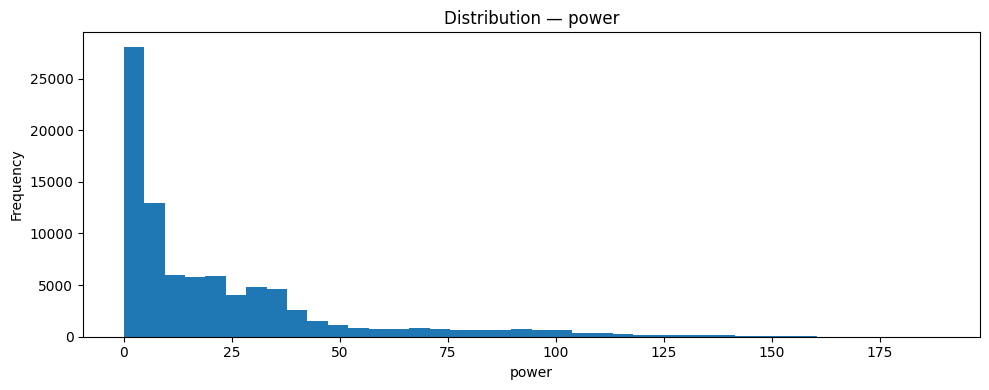

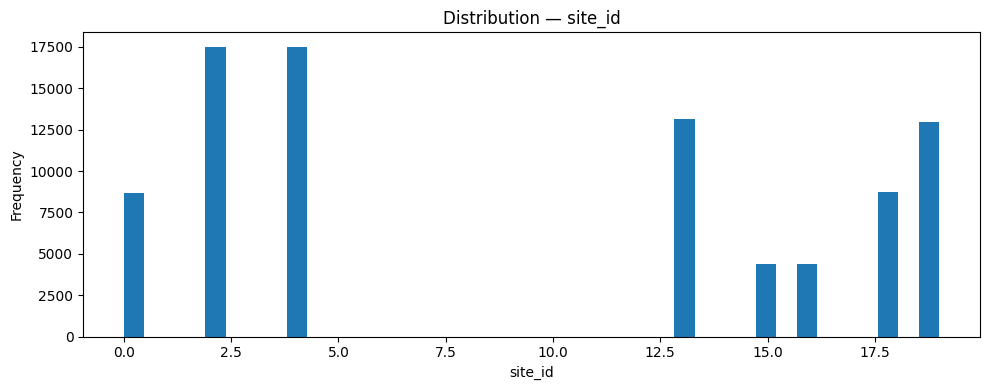

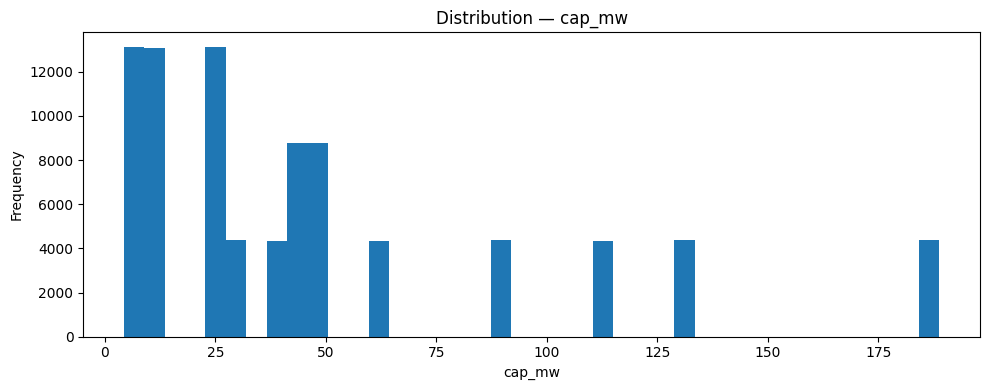

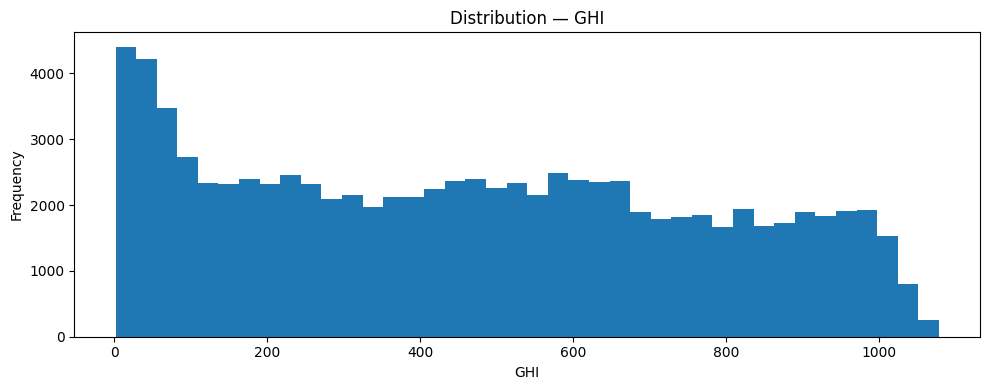

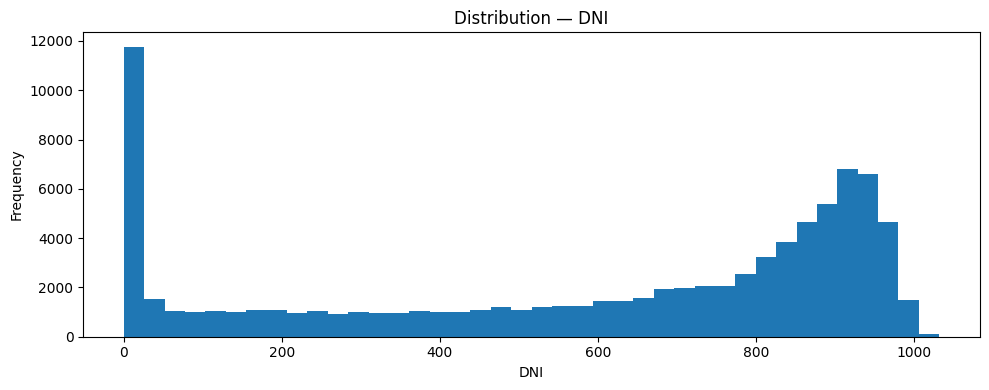

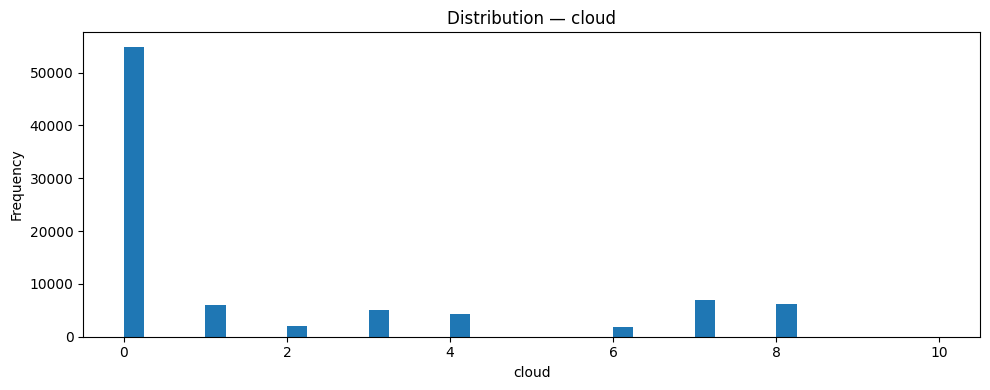

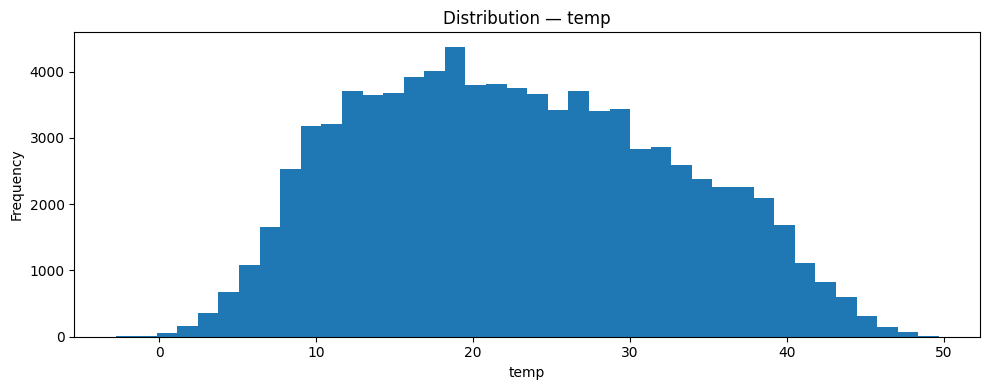

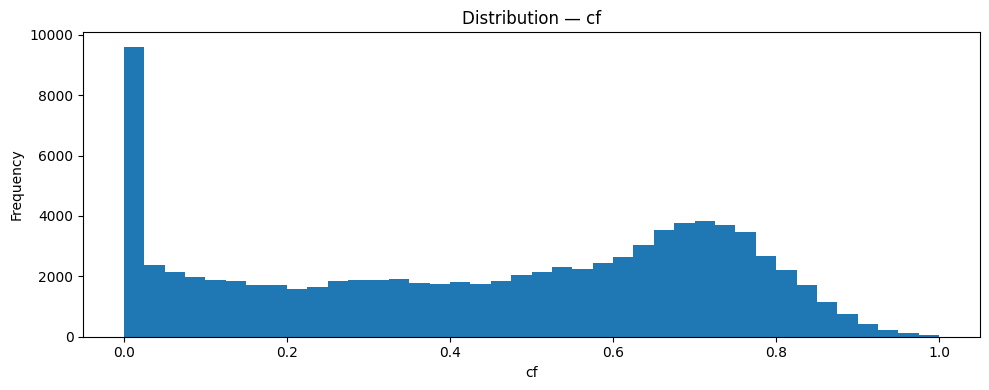

In [17]:
if numeric_cols:
    for col in numeric_cols:
        s = df[col].dropna()

        plt.figure(figsize=(10, 4))
        plt.hist(s, bins=40)
        plt.title(f"Distribution — {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns to visualize.")

## 5. Boxplots and descriptive outlier inspection

Outliers are **reported, not removed**. In solar data, extreme observations can be meaningful operating conditions rather than errors.

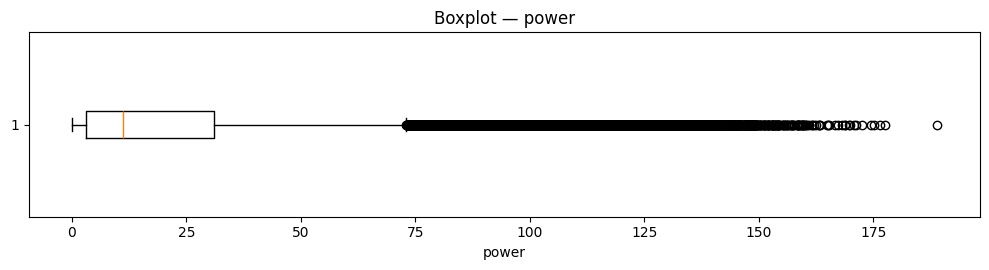

power: IQR range [-38.85, 73.05], flagged observations = 6,542 (7.49%)


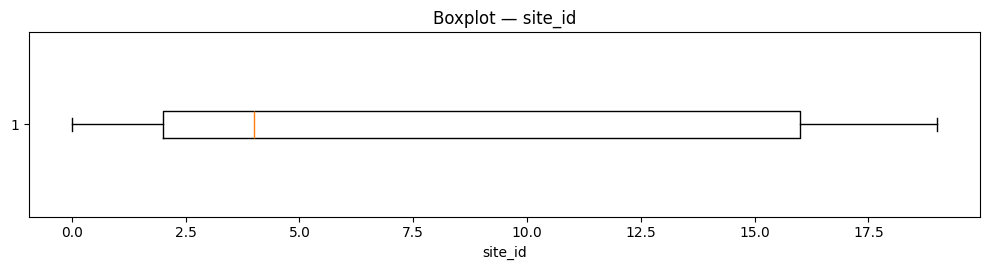

site_id: IQR range [-19, 37], flagged observations = 0 (0.00%)


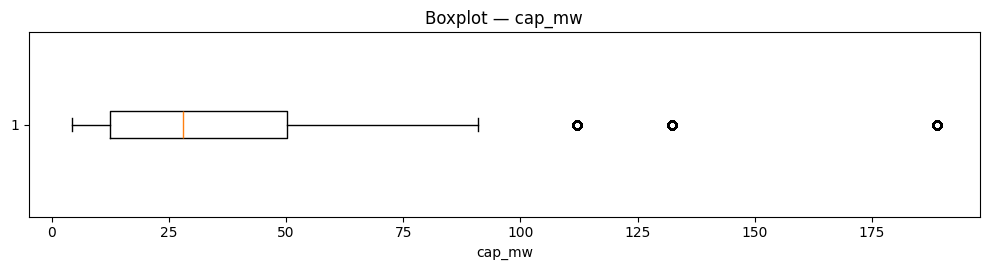

cap_mw: IQR range [-44.18, 106.8], flagged observations = 13,069 (14.97%)


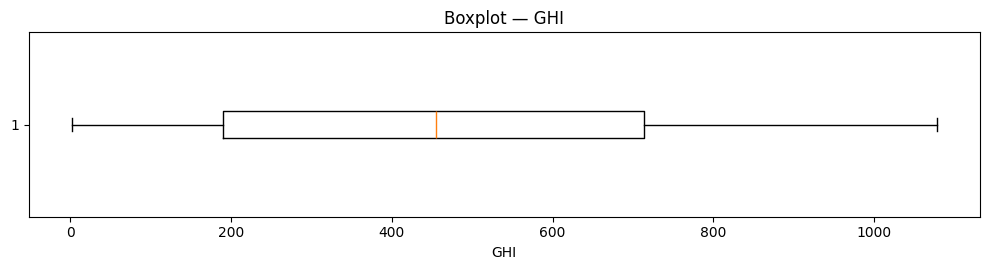

GHI: IQR range [-596, 1500], flagged observations = 0 (0.00%)


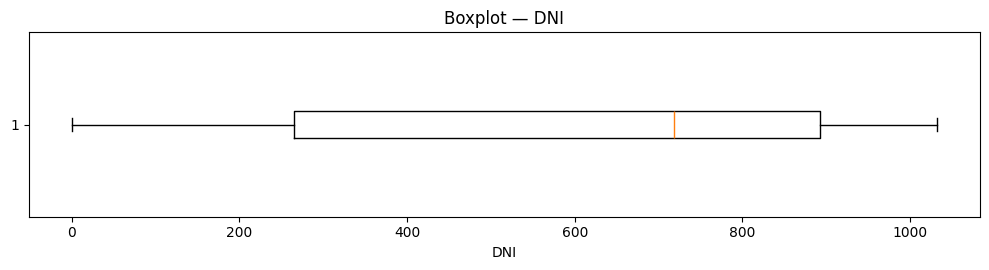

DNI: IQR range [-677, 1835], flagged observations = 0 (0.00%)


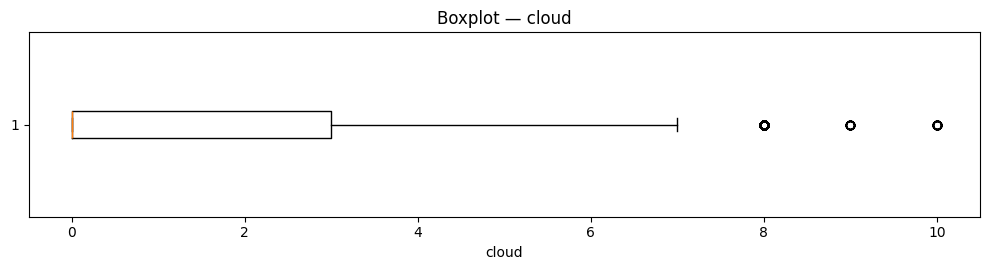

cloud: IQR range [-4.5, 7.5], flagged observations = 6,203 (7.11%)


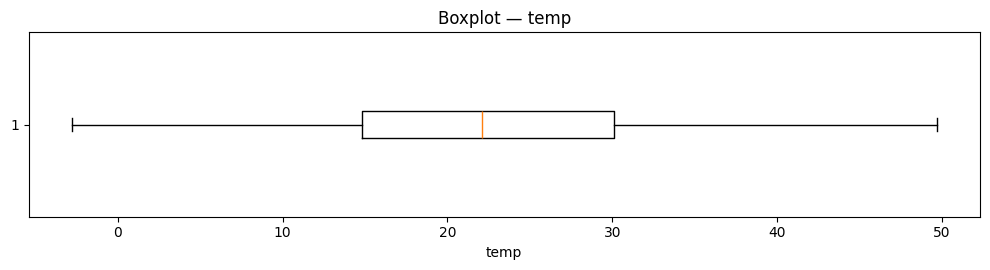

temp: IQR range [-8.15, 53.05], flagged observations = 0 (0.00%)


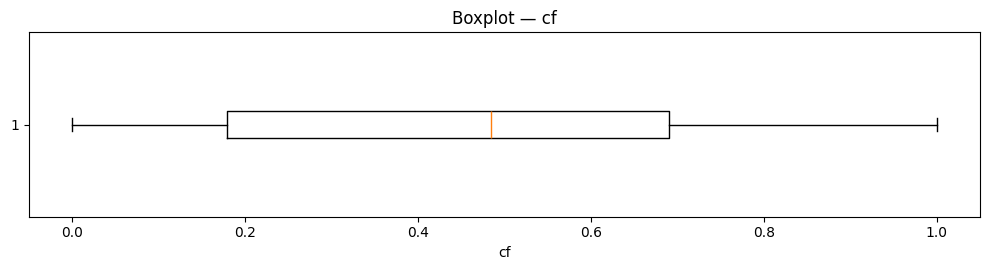

cf: IQR range [-0.5874, 1.456], flagged observations = 0 (0.00%)


In [18]:
if numeric_cols:
    for col in numeric_cols:
        plt.figure(figsize=(10, 2.8))
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(f"Boxplot — {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        if pd.notna(iqr) and iqr != 0:
            count = int(((df[col] < lower) | (df[col] > upper)).sum())
            print(
                f"{col}: IQR range [{lower:.4g}, {upper:.4g}], "
                f"flagged observations = {count:,} ({count / max(len(df), 1) * 100:.2f}%)"
            )
else:
    print("No numeric columns to analyze.")

## 6. Correlation analysis

Correlation is exploratory and does **not** prove causation. Focus on strong relationships that may be useful for later analysis or modeling.

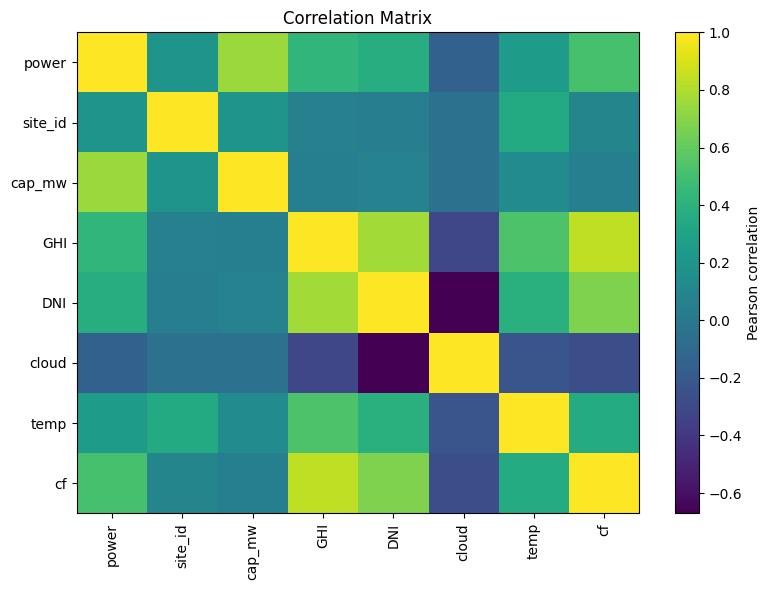

,feature_1,feature_2,correlation,abs_correlation
21,GHI,cf,0.840026,0.840026
18,GHI,DNI,0.765469,0.765469
1,power,cap_mw,0.747568,0.747568
24,DNI,cf,0.679542,0.679542
22,DNI,cloud,-0.670247,0.670247
20,GHI,temp,0.532978,0.532978
6,power,cf,0.517015,0.517015
2,power,GHI,0.428271,0.428271
23,DNI,temp,0.392308,0.392308
3,power,DNI,0.370080,0.370080


In [19]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(max(8, 0.8 * len(numeric_cols)),
                        max(6, 0.7 * len(numeric_cols))))
    plt.imshow(corr, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Pearson correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # strongest unique pairs
    pairs = []
    for i, c1 in enumerate(corr.columns):
        for j, c2 in enumerate(corr.columns):
            if j <= i:
                continue
            value = corr.loc[c1, c2]
            if pd.notna(value):
                pairs.append((c1, c2, value, abs(value)))

    strongest = (
        pd.DataFrame(
            pairs,
            columns=["feature_1", "feature_2", "correlation", "abs_correlation"]
        )
        .sort_values("abs_correlation", ascending=False)
        .head(20)
    )

    display(strongest)
else:
    print("Need at least two numeric columns for correlation analysis.")

## 7. Datetime / time-series EDA

This section searches for columns that are already datetime typed or have date/time-like names. It does not alter the dataset.

In [20]:
datetime_cols = list(df.select_dtypes(include=["datetime", "datetimetz"]).columns)

name_based_datetime_candidates = [
    c for c in df.columns
    if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])
]

print("Datetime-typed columns:", datetime_cols)
print("Date/time-like column names:", name_based_datetime_candidates)

for col in datetime_cols:
    s = df[col].dropna()

    print(f"\n### {col}")
    print("Start:", s.min())
    print("End:", s.max())
    print("Unique timestamps:", s.nunique())

    if len(s) >= 2:
        diffs = s.sort_values().diff().dropna()
        print("Most common sampling intervals:")
        display(diffs.value_counts().head(10).rename("count").to_frame())

Datetime-typed columns: ['time']
Date/time-like column names: ['time']

### time
Start: 2006-01-01 07:00:00
End: 2006-12-31 17:00:00
Unique timestamps: 4661
Most common sampling intervals:


,count
time,
0 days 00:00:00,82641
0 days 01:00:00,4296
0 days 11:00:00,80
0 days 10:00:00,70
0 days 13:00:00,63
0 days 14:00:00,61
0 days 12:00:00,51
0 days 15:00:00,39


## 8. Solar-specific relationships

Where the column names make this possible, inspect relationships among common solar measurements such as irradiance, temperature, wind, humidity, and power/energy generation.

The code only visualizes columns that actually exist.

irradiance: ['GHI', 'DNI']
power: ['power']
energy: []
temperature: ['temp']
humidity: []
wind: []


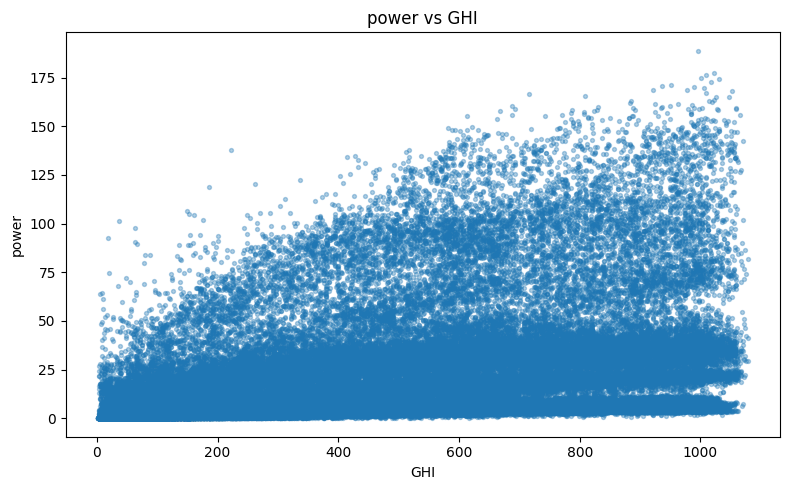

Pearson correlation: 0.4283


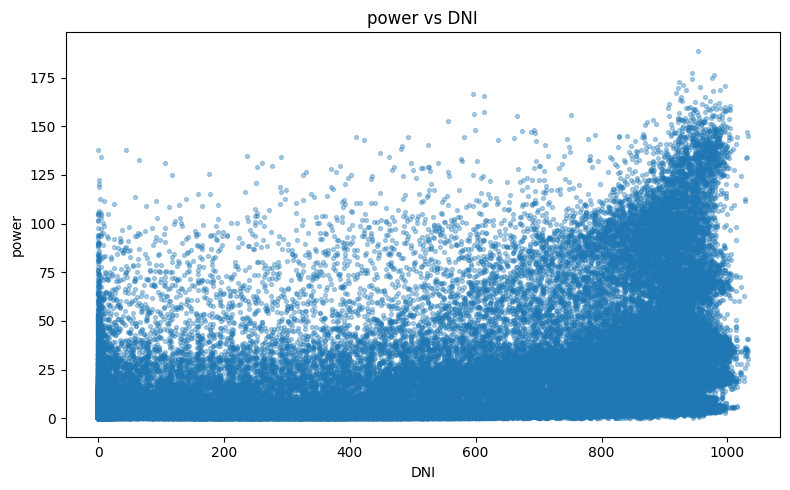

Pearson correlation: 0.3701


In [21]:
def find_columns(keywords):
    return [
        c for c in df.columns
        if any(k in c.lower() for k in keywords)
    ]

solar_groups = {
    "irradiance": find_columns(["irradiance", "radiation", "solar_radiation", "ghi", "dni", "dhi"]),
    "power": find_columns(["power", "generation", "generated", "output"]),
    "energy": find_columns(["energy", "yield"]),
    "temperature": find_columns(["temp", "temperature"]),
    "humidity": find_columns(["humidity", "humid"]),
    "wind": find_columns(["wind", "windspeed", "wind_speed"]),
}

for group, cols in solar_groups.items():
    print(f"{group}: {cols}")

irr_cols = solar_groups["irradiance"]
power_cols = solar_groups["power"]

for x in irr_cols[:3]:
    for y in power_cols[:3]:
        tmp = df[[x, y]].dropna()

        if tmp.empty:
            continue

        plt.figure(figsize=(8, 5))
        plt.scatter(tmp[x], tmp[y], s=8, alpha=0.35)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{y} vs {x}")
        plt.tight_layout()
        plt.show()

        print(f"Pearson correlation: {tmp[x].corr(tmp[y]):.4f}")

## 9. Time-based solar trends

For a detected datetime column, this section plots available solar-related numeric variables against time. This helps reveal daily/seasonal patterns, trend changes, gaps, and volatility.

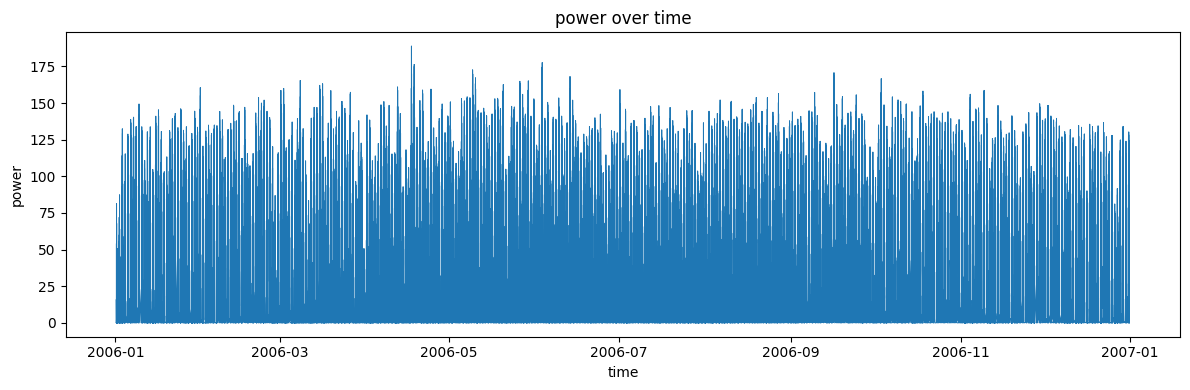

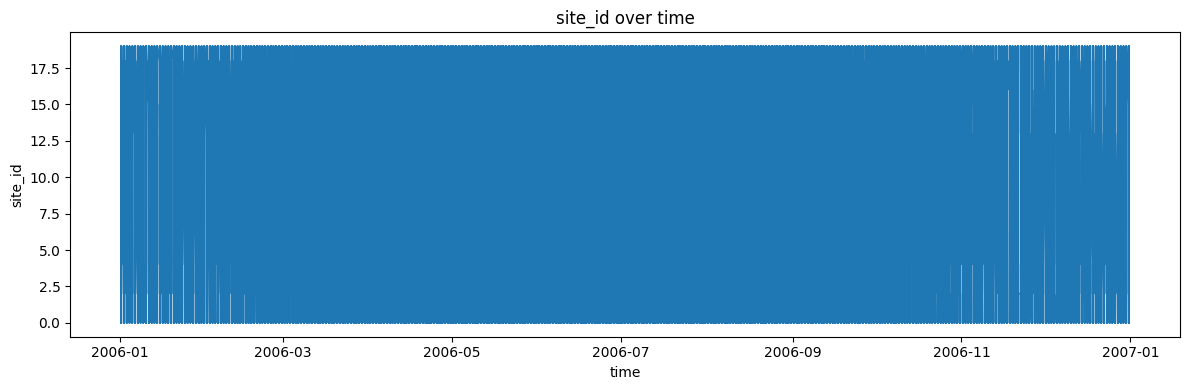

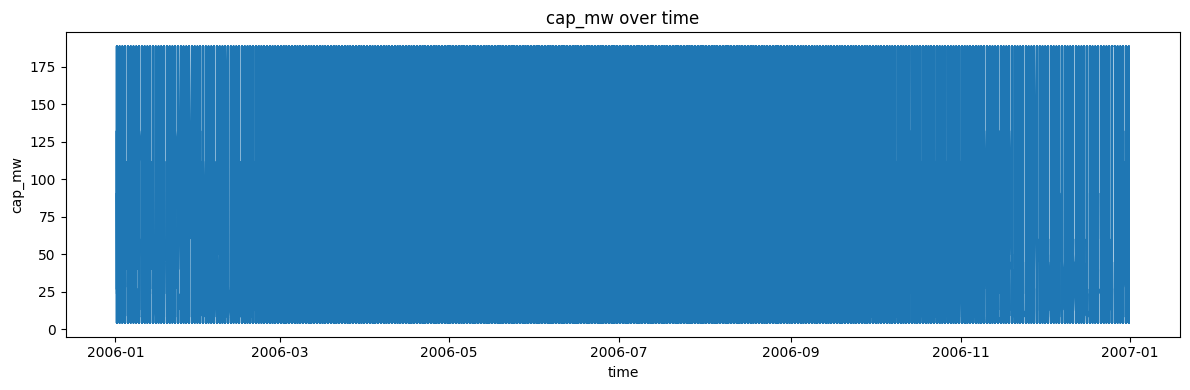

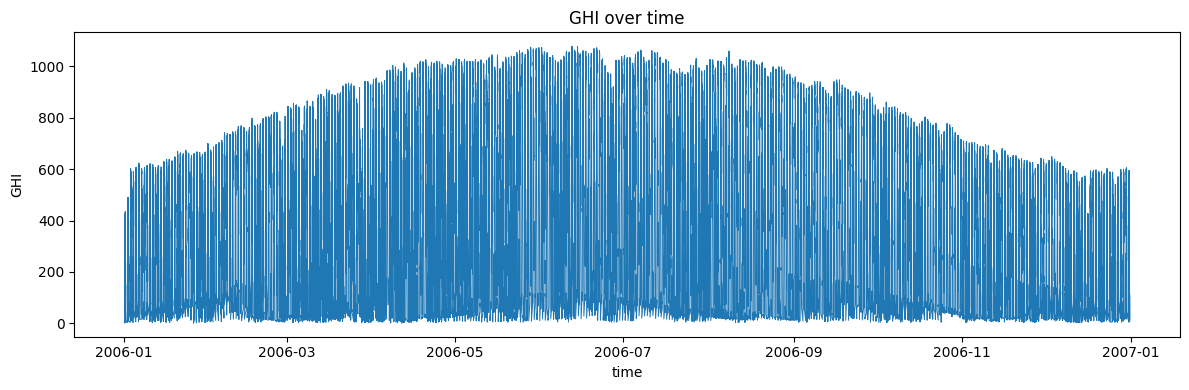

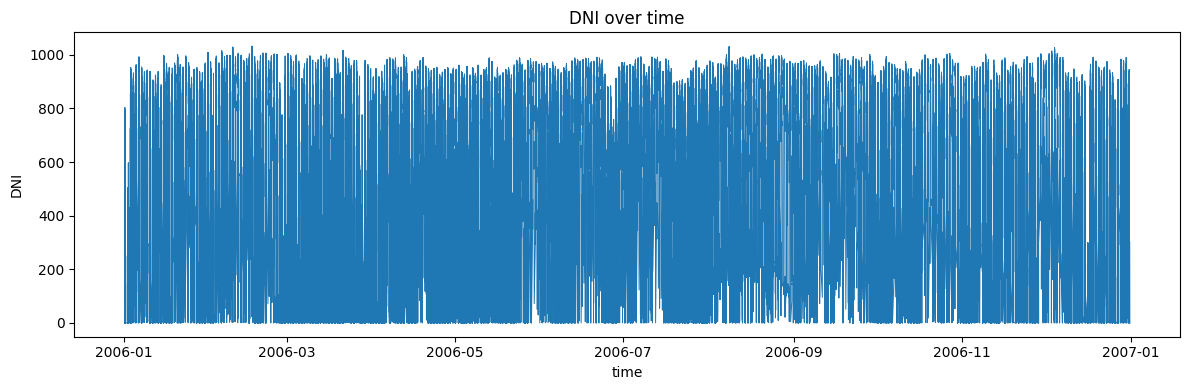

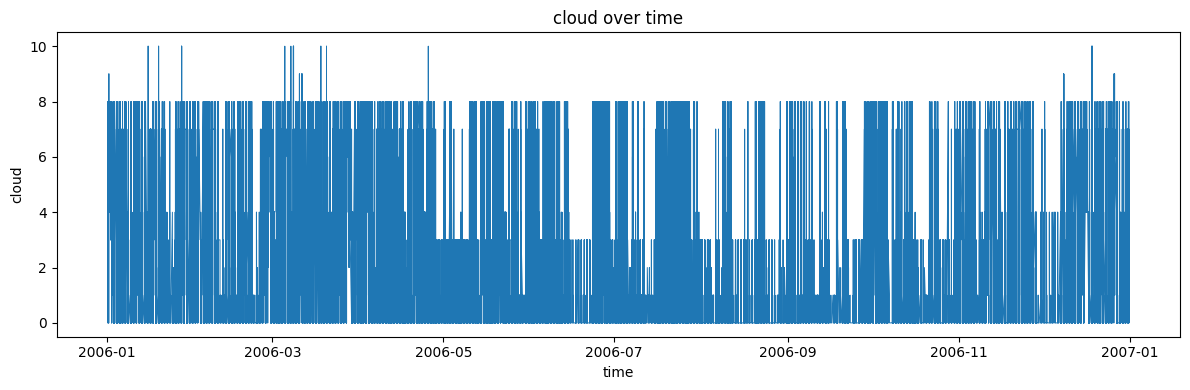

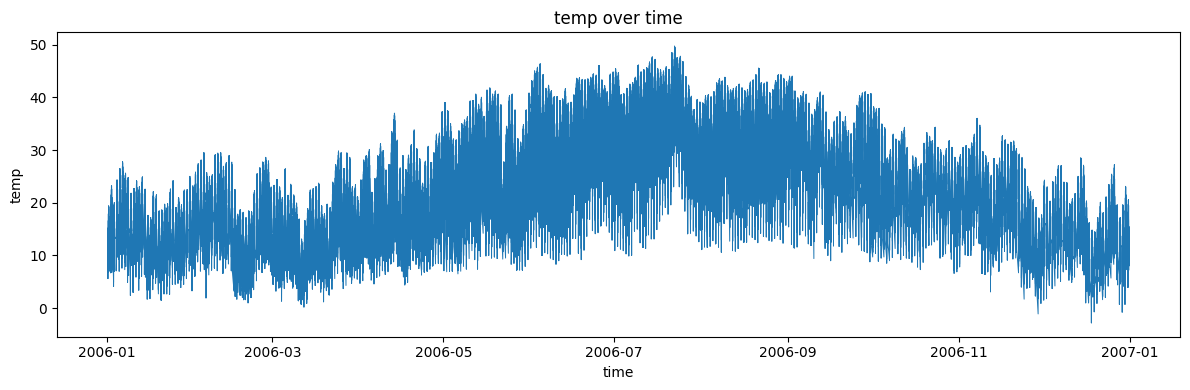

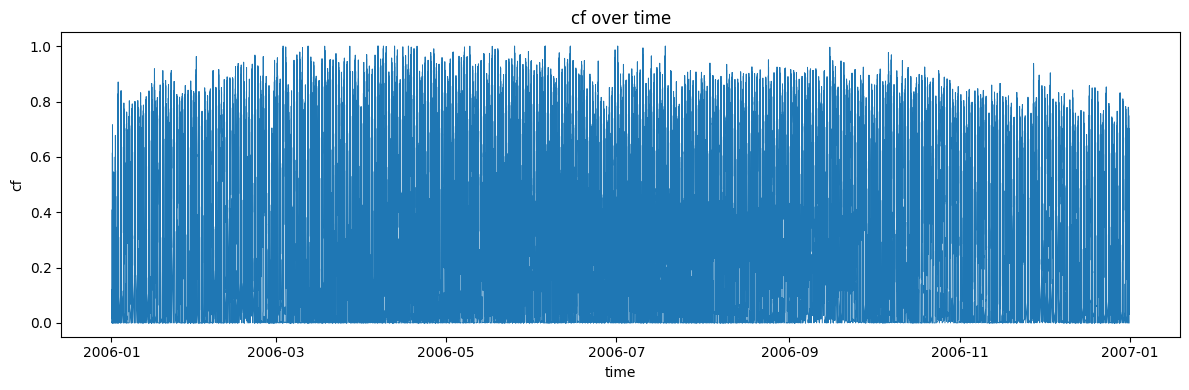

In [26]:
if datetime_cols and numeric_cols:
    time_col = datetime_cols[0]

    temp = df[[time_col] + numeric_cols].copy()
    temp = temp.sort_values(time_col)

    for col in numeric_cols:
        plot_df = temp[[time_col, col]].dropna()

        if plot_df.empty:
            continue

        plt.figure(figsize=(12, 4))
        plt.plot(plot_df[time_col], plot_df[col], linewidth=0.7)
        plt.title(f"{col} over time")
        plt.xlabel(time_col)
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
else:
    print("No datetime-typed column and numeric variables were found for time-series plots.")

## 10. Automated EDA findings table

This section creates a compact pandas table of useful descriptive signals.

In [23]:
findings = []

for col in numeric_cols:
    s = df[col].dropna()

    if s.empty:
        continue

    mean = s.mean()
    median = s.median()
    std = s.std()
    cv = std / mean if pd.notna(mean) and mean != 0 else np.nan

    findings.append({
        "column": col,
        "min": s.min(),
        "median": median,
        "mean": mean,
        "max": s.max(),
        "std": std,
        "skew": s.skew(),
        "coefficient_of_variation": cv,
        "unique": s.nunique(),
    })

findings_df = pd.DataFrame(findings)

if not findings_df.empty:
    display(
        findings_df.sort_values(
            "coefficient_of_variation",
            ascending=False,
            na_position="last"
        )
    )
else:
    print("No numeric findings available.")

,column,min,median,mean,max,std,skew,coefficient_of_variation,unique
5,cloud,0.0000,0.000000,1.742434,10.000,2.771291,1.322414,1.590471,10
0,power,0.0000,11.216667,22.198298,188.825,27.786556,1.987176,1.251743,19391
2,cap_mw,4.3025,28.108333,48.733984,188.825,46.961476,1.566682,0.963629,20
1,site_id,0.0000,4.000000,9.336682,19.000,7.241292,0.104703,0.775575,8
3,GHI,2.0000,455.000000,465.047158,1078.000,305.558049,0.167630,0.657047,1074
7,cf,0.0000,0.484681,0.441027,1.000,0.279719,-0.201869,0.634244,51837
4,DNI,0.0000,719.000000,587.094316,1032.000,347.230616,-0.580799,0.591439,1024
6,temp,-2.8000,22.100000,22.699939,49.700,9.877808,0.191559,0.435147,484


# 11. Research Question: How output depends on irradiance, cloud cover and season across plants

### Research question
**How does solar output depend on irradiance, cloud cover and season across plants?**

### Analysis strategy
- **Output:** use `power` for raw plant output and `cf` (capacity factor) for fair comparison across plants with different capacities.
- **Irradiance:** use `GHI` as the main global irradiance measure.
- **Cloud cover:** use `cloud` as supplied in the cleaned dataset.
- **Season:** derive an analysis-only season label from `time`:
  - Winter = Dec–Feb
  - Spring = Mar–May
  - Summer = Jun–Aug
  - Fall = Sep–Nov
- **Across plants:** calculate the relationships separately for each `plant`, rather than relying only on pooled data.

> This section is **EDA only**. It does not clean, impute, delete, deduplicate, or modify the supplied data. The season and irradiance-bin labels are temporary analysis variables.

## 11.1 Prepare analysis variables

We keep the original `df` unchanged and create `eda` only for grouping and visualization.

In [ ]:
eda = df.copy()

# Analysis-only time labels.
eda["month"] = eda["time"].dt.month
eda["season"] = pd.cut(
    eda["month"],
    bins=[0, 2, 5, 8, 11, 12],
    labels=["Winter", "Spring", "Summer", "Fall", "Winter"],
    ordered=False
)

# The first/last bins above split winter across December and Jan-Feb.
# Explicit mapping keeps the intended four seasons unambiguous.
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
}
eda["season"] = eda["month"].map(season_map)

# Numeric month order for plots.
season_order = ["Winter", "Spring", "Summer", "Fall"]
eda["season"] = pd.Categorical(eda["season"], categories=season_order, ordered=True)

print("Plants:", eda["plant"].nunique())
print("Date range:", eda["time"].min(), "to", eda["time"].max())
print("Seasons:", eda["season"].value_counts().reindex(season_order))

## 11.2 Output and plant baseline

Because `power` is measured in MW and plant capacities differ, raw power alone can make larger plants look better simply because they are larger.

`cf` is therefore the main output measure for **across-plant comparison**, while `power` remains useful for describing actual output.

In [ ]:
plant_baseline = (
    eda.groupby("plant", observed=True)
       .agg(
           observations=("plant", "size"),
           site_id=("site_id", "first"),
           capacity_mw=("cap_mw", "first"),
           mean_power_mw=("power", "mean"),
           median_power_mw=("power", "median"),
           mean_cf=("cf", "mean"),
           median_cf=("cf", "median"),
           mean_GHI=("GHI", "mean"),
           mean_cloud=("cloud", "mean"),
       )
       .sort_values("mean_cf", ascending=False)
)

display(plant_baseline)

## 11.3 Overall dependence: irradiance, cloud cover and output

Start with the pooled dataset to establish the overall pattern.

We report both **Pearson** (linear association) and **Spearman** (monotonic association), because solar output relationships do not have to be perfectly linear.

In [ ]:
overall_corr = pd.DataFrame({
    "Pearson_corr_with_cf": [
        eda["GHI"].corr(eda["cf"], method="pearson"),
        eda["cloud"].corr(eda["cf"], method="pearson"),
    ],
    "Spearman_corr_with_cf": [
        eda["GHI"].corr(eda["cf"], method="spearman"),
        eda["cloud"].corr(eda["cf"], method="spearman"),
    ]
}, index=["GHI (irradiance)", "Cloud cover"])

display(overall_corr)

print(
    f"Overall GHI vs CF: Pearson={overall_corr.loc['GHI (irradiance)', 'Pearson_corr_with_cf']:.3f}, "
    f"Spearman={overall_corr.loc['GHI (irradiance)', 'Spearman_corr_with_cf']:.3f}"
)
print(
    f"Overall cloud vs CF: Pearson={overall_corr.loc['Cloud cover', 'Pearson_corr_with_cf']:.3f}, "
    f"Spearman={overall_corr.loc['Cloud cover', 'Spearman_corr_with_cf']:.3f}"
)

In [ ]:
# Main relationship plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(eda["GHI"], eda["cf"], s=7, alpha=0.18)
axes[0].set_title("Capacity factor vs GHI")
axes[0].set_xlabel("GHI")
axes[0].set_ylabel("Capacity factor (cf)")

axes[1].scatter(eda["cloud"], eda["cf"], s=7, alpha=0.18)
axes[1].set_title("Capacity factor vs cloud cover")
axes[1].set_xlabel("Cloud cover")
axes[1].set_ylabel("Capacity factor (cf)")

plt.tight_layout()
plt.show()

## 11.4 Does the irradiance relationship hold across plants?

A pooled correlation can hide plant-level differences. Here we calculate the GHI → CF relationship separately for every plant.

In [ ]:
plant_relationships = []

for plant, g in eda.groupby("plant", observed=True):
    plant_relationships.append({
        "plant": plant,
        "n": len(g),
        "capacity_mw": g["cap_mw"].iloc[0],
        "mean_cf": g["cf"].mean(),
        "ghi_pearson_cf": g["GHI"].corr(g["cf"], method="pearson"),
        "ghi_spearman_cf": g["GHI"].corr(g["cf"], method="spearman"),
        "cloud_pearson_cf": g["cloud"].corr(g["cf"], method="pearson"),
        "cloud_spearman_cf": g["cloud"].corr(g["cf"], method="spearman"),
    })

plant_relationships = (
    pd.DataFrame(plant_relationships)
      .sort_values("ghi_spearman_cf", ascending=False)
)

display(plant_relationships)

In [ ]:
# Visualize plant-level GHI dependence.
plants = plant_relationships["plant"].tolist()
ncols = 4
nrows = math.ceil(len(plants) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)

for ax, plant in zip(axes.flat, plants):
    g = eda[eda["plant"] == plant].copy()

    # Rank-based GHI quintiles avoid relying on common absolute GHI ranges.
    g["ghi_q"] = pd.qcut(
        g["GHI"].rank(method="first"),
        5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )

    profile = g.groupby("ghi_q", observed=True)["cf"].median()

    ax.plot(profile.index.astype(str), profile.values, marker="o")
    corr = plant_relationships.loc[
        plant_relationships["plant"] == plant, "ghi_spearman_cf"
    ].iloc[0]

    ax.set_title(f"{plant}\nSpearman={corr:.2f}")
    ax.set_xlabel("Plant-specific GHI quintile")
    ax.set_ylabel("Median CF")
    ax.grid(alpha=0.2)

for ax in axes.flat[len(plants):]:
    ax.axis("off")

plt.suptitle("Plant-level output response to irradiance", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## 11.5 Does more cloud cover reduce output?

Because `cloud` is an integer index from 0 to 10 in this dataset, use explicit groups to make the output differences easy to interpret.

In [ ]:
cloud_bins = [-0.1, 0.5, 2.5, 5.5, 8.5, 10.1]
cloud_labels = ["0: clear", "1–2: low", "3–5: moderate", "6–8: high", "9–10: very high"]

eda["cloud_group"] = pd.cut(
    eda["cloud"],
    bins=cloud_bins,
    labels=cloud_labels,
    include_lowest=True
)

cloud_effect = (
    eda.groupby(["plant", "cloud_group"], observed=True)["cf"]
       .agg(["mean", "median", "count"])
       .reset_index()
)

display(cloud_effect.head(25))

# Across-plant cloud profile: first summarize within plant, then average plants
# so plants with slightly different observation counts do not dominate.
plant_cloud_profile = (
    cloud_effect.groupby("cloud_group", observed=True)["mean"]
                .agg(["mean", "std", "min", "max"])
                .reindex(cloud_labels)
)

display(plant_cloud_profile)

plt.figure(figsize=(10, 5))
plt.errorbar(
    plant_cloud_profile.index.astype(str),
    plant_cloud_profile["mean"],
    yerr=plant_cloud_profile["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Cloud-cover group")
plt.ylabel("Mean plant-level capacity factor")
plt.title("Capacity factor decreases as cloud cover changes")
plt.tight_layout()
plt.show()

## 11.6 Season effect across plants

Season can change output through changes in solar availability over the year. Compare seasons using capacity factor, then inspect whether the seasonal pattern is consistent across plants.

In [ ]:
season_by_plant = (
    eda.groupby(["plant", "season"], observed=True)
       .agg(
           mean_cf=("cf", "mean"),
           median_cf=("cf", "median"),
           mean_power_mw=("power", "mean"),
           mean_GHI=("GHI", "mean"),
           mean_cloud=("cloud", "mean"),
           observations=("cf", "size")
       )
       .reset_index()
)

display(season_by_plant.head(20))

season_heatmap = season_by_plant.pivot(
    index="plant",
    columns="season",
    values="mean_cf"
).reindex(columns=season_order)

display(season_heatmap)

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(season_heatmap.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Mean capacity factor")
plt.xticks(range(len(season_order)), season_order)
plt.yticks(range(len(season_heatmap.index)), season_heatmap.index)
plt.xlabel("Season")
plt.ylabel("Plant")
plt.title("Mean capacity factor by plant and season")
plt.tight_layout()
plt.show()

In [ ]:
# Seasonal spread for every plant.
season_spread = (
    season_heatmap.assign(
        seasonal_range=lambda x: x.max(axis=1) - x.min(axis=1),
        best_season=lambda x: x[season_order].idxmax(axis=1),
        lowest_season=lambda x: x[season_order].idxmin(axis=1)
    )
    .sort_values("seasonal_range", ascending=False)
)

display(season_spread[season_order + ["seasonal_range", "best_season", "lowest_season"]])

## 11.7 Combined effect: irradiance × cloud cover × season

The research question is not only about each variable separately. This section checks whether the output pattern changes when irradiance and cloud cover are considered together, and whether the pattern differs by season.

In [ ]:
# Use three within-plant GHI groups so plants are compared relative to their own
# irradiance distribution.
eda["ghi_level"] = (
    eda.groupby("plant")["GHI"]
       .rank(method="first", pct=True)
       .pipe(
           lambda s: pd.cut(
               s,
               bins=[0, 1/3, 2/3, 1],
               labels=["Low GHI", "Mid GHI", "High GHI"],
               include_lowest=True
           )
       )
)

combined = (
    eda.groupby(
        ["season", "ghi_level", "cloud_group"],
        observed=True
    )["cf"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

display(combined.head(30))

In [ ]:
# Heatmaps: within each season, show mean CF by relative GHI level and cloud level.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), squeeze=False)

for ax, season in zip(axes.flat, season_order):
    temp = combined[combined["season"] == season]

    pivot = temp.pivot(
        index="ghi_level",
        columns="cloud_group",
        values="mean"
    ).reindex(
        index=["Low GHI", "Mid GHI", "High GHI"],
        columns=cloud_labels
    )

    im = ax.imshow(pivot.values, aspect="auto", interpolation="nearest")
    ax.set_title(season)
    ax.set_xticks(range(len(cloud_labels)))
    ax.set_xticklabels(cloud_labels, rotation=35, ha="right")
    ax.set_yticks(range(3))
    ax.set_yticklabels(["Low GHI", "Mid GHI", "High GHI"])
    ax.set_xlabel("Cloud cover")
    ax.set_ylabel("Relative irradiance")

fig.colorbar(im, ax=axes.ravel().tolist(), label="Mean capacity factor")
fig.suptitle("Combined irradiance and cloud-cover relationship with output", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## 11.8 Final plant-level summary for the research question

This table brings all three dimensions together so the research question can be answered directly for each plant.

In [ ]:
# Irradiance response: compare low vs high plant-specific GHI quintiles.
ghi_response_rows = []

for plant, g in eda.groupby("plant", observed=True):
    q = pd.qcut(
        g["GHI"].rank(method="first"),
        5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )
    tmp = g.copy()
    tmp["ghi_q"] = q

    cf_by_q = tmp.groupby("ghi_q", observed=True)["cf"].mean()
    ghi_response_rows.append({
        "plant": plant,
        "ghi_low_cf": cf_by_q.get("Q1", np.nan),
        "ghi_high_cf": cf_by_q.get("Q5", np.nan),
        "ghi_response_high_minus_low": cf_by_q.get("Q5", np.nan) - cf_by_q.get("Q1", np.nan),
    })

ghi_response = pd.DataFrame(ghi_response_rows)

# Cloud response: clear vs very high cloud.
cloud_response = (
    eda.groupby(["plant", "cloud_group"], observed=True)["cf"]
       .mean()
       .unstack()
       .reindex(columns=cloud_labels)
)

cloud_response_summary = pd.DataFrame({
    "cloud_clear_cf": cloud_response.get("0: clear"),
    "cloud_very_high_cf": cloud_response.get("9–10: very high"),
})
cloud_response_summary["cloud_response_clear_minus_high"] = (
    cloud_response_summary["cloud_clear_cf"] -
    cloud_response_summary["cloud_very_high_cf"]
)

# Seasonal response.
season_summary = (
    season_heatmap
    .assign(
        seasonal_range=lambda x: x[season_order].max(axis=1) - x[season_order].min(axis=1)
    )
)

final_rq_summary = (
    plant_relationships[
        ["plant", "capacity_mw", "mean_cf",
         "ghi_spearman_cf", "cloud_spearman_cf"]
    ]
    .merge(ghi_response, on="plant", how="left")
    .merge(cloud_response_summary, left_on="plant", right_index=True, how="left")
    .merge(
        season_summary[["seasonal_range"]],
        left_on="plant",
        right_index=True,
        how="left"
    )
)

display(
    final_rq_summary
    .sort_values("plant")
    .reset_index(drop=True)
)

## 11.9 Data-driven conclusion for the research question

Run the final cell below after all previous cells. It converts the calculated EDA results into a presentation-ready conclusion without inventing claims.

In [ ]:
overall_ghi = overall_corr.loc["GHI (irradiance)", "Spearman_corr_with_cf"]
overall_cloud = overall_corr.loc["Cloud cover", "Spearman_corr_with_cf"]

mean_season_cf = season_heatmap.mean(axis=0)
highest_mean_season = mean_season_cf.idxmax()
lowest_mean_season = mean_season_cf.idxmin()

positive_ghi_share = (plant_relationships["ghi_spearman_cf"] > 0).mean()
negative_cloud_share = (plant_relationships["cloud_spearman_cf"] < 0).mean()

print("RESEARCH QUESTION")
print("How output depends on irradiance, cloud cover and season across plants?\n")

print(f"1. Irradiance: overall Spearman correlation between GHI and CF = {overall_ghi:.3f}.")
print(f"   {positive_ghi_share:.0%} of plants have a positive within-plant GHI–CF Spearman correlation.")

print(f"2. Cloud cover: overall Spearman correlation between cloud cover and CF = {overall_cloud:.3f}.")
print(f"   {negative_cloud_share:.0%} of plants have a negative within-plant cloud–CF Spearman correlation.")

print(
    f"3. Season: across all plants, the highest mean CF occurs in {highest_mean_season} "
    f"({mean_season_cf[highest_mean_season]:.3f}), while the lowest occurs in "
    f"{lowest_mean_season} ({mean_season_cf[lowest_mean_season]:.3f})."
)

print(
    "\n4. Interpretation: use the plant-level tables and the four seasonal heatmaps "
    "to determine whether the irradiance and cloud-cover relationships remain consistent "
    "or vary by season and plant."
)

print(
    "\nImportant: this is exploratory association, not a causal estimate. "
    "The patterns describe how the observed output co-moves with the observed "
    "irradiance, cloud cover, and season variables."
)